In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import json

from loguru import logger
from pymatgen.core import Structure

from src.datasets import MaterialsProject

In [4]:
mp = MaterialsProject(sampling_strategy="head", add_acsf=False, add_soap=False)
df = mp.load(limit=None, force_fetch=False)

2026-04-22 15:11:35.511 | INFO     | src.datasets:load:1355 - Loading full cached Parquet data from data/Materials Project/materials.parquet...


In [6]:
df['pearson_symbol'].unique()

pearson_symbol
str
"""hR42"""
"""mP14"""
"""oP12"""
"""oF32"""
"""oF44"""
…
"""oC12"""
"""cF40"""
"""mP34"""


# Plots for investegating

In [5]:
def plot_crystal_system_diversity(df: pl.DataFrame):
    """
    Generates a bar plot showing the distribution of crystal systems.
    """
    logger.info("Generating Crystal System distribution plot...")
    
    crystal_counts = (
        df.group_by("crystal_system")
        .len()
        .sort("len", descending=True)
    )

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Fix: Added x as hue and set legend=False to satisfy new Seaborn syntax
    ax = sns.barplot(
        x=crystal_counts["crystal_system"].to_list(),
        y=crystal_counts["len"].to_list(),
        hue=crystal_counts["crystal_system"].to_list(),
        palette="magma",
        edgecolor=".2",
        legend=False 
    )

    plt.title("Materials Project: Diversity of Crystal Systems", fontsize=15, fontweight='bold')
    plt.xlabel("Crystal System", fontsize=12)
    plt.ylabel("Count (Number of Materials)", fontsize=12)
    plt.xticks(rotation=45)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/crystal_system_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_volume_distribution(df: pl.DataFrame):
    """
    Generates a KDE plot for Lattice Volume distribution across crystal systems.
    """
    logger.info("Generating Volume Distribution plot...")
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="white")

    # Fix: Capture the axes object 'ax'
    ax = sns.kdeplot(
        data=df.to_pandas(), 
        x='volume', 
        hue='crystal_system', 
        fill=True, 
        common_norm=False, 
        alpha=0.4,
        palette="viridis"
    )

    plt.title("Materials Project: Lattice Volume Distribution by Crystal System", fontsize=15, fontweight='bold')
    plt.xlabel("Lattice Volume (Å³)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    
    # Fix: Use sns.move_legend instead of plt.legend()
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Crystal System")
    
    plt.tight_layout()
    plt.savefig('report/materials_project/figures/initial_analysis/volume_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    logger.success("Visualization complete.")

2026-03-30 08:12:24.023 | INFO     | __main__:plot_crystal_system_diversity:5 - Generating Crystal System distribution plot...


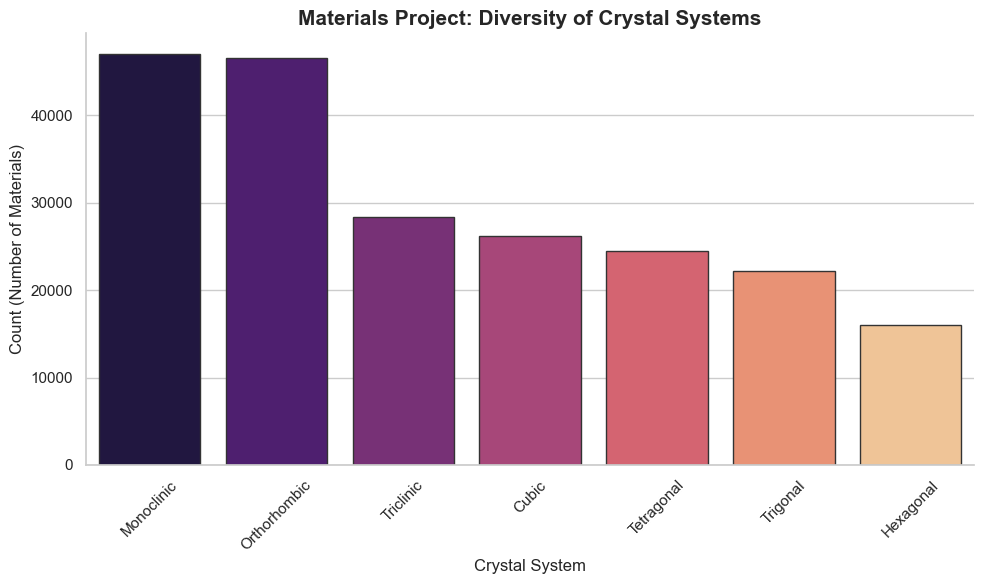

2026-03-30 08:12:24.366 | INFO     | __main__:plot_volume_distribution:40 - Generating Volume Distribution plot...


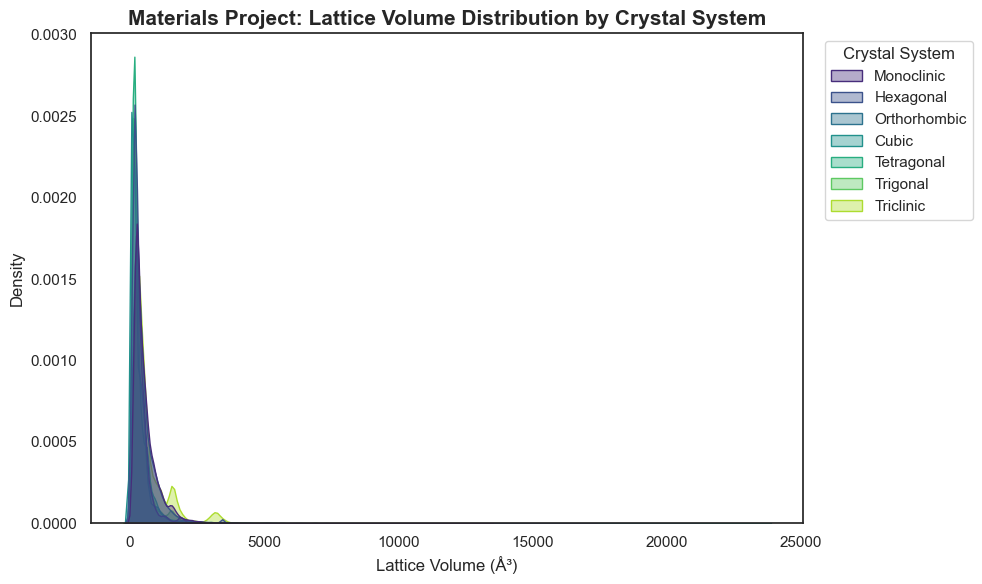

2026-03-30 08:12:26.336 | SUCCESS  | __main__:plot_volume_distribution:66 - Visualization complete.


In [6]:
plot_crystal_system_diversity(mp.df)
plot_volume_distribution(mp.df)

# Show raw structure

In [6]:
mp.df['formula_pretty'][0]

'Cs4Al3InSb16'

In [7]:
struct_json = mp.df["raw_structure"][0]
struct = Structure.from_dict(json.loads(struct_json))
print(struct)
struct

Full Formula (Cs4 Al3 In1 Sb16)
Reduced Formula: Cs4Al3InSb16
abc   :   4.299848  11.029108  18.923066
angles:  90.165696  90.000000  90.000000
pbc   :       True       True       True
Sites (24)
  #  SP       a         b         c    magmom
---  ----  ----  --------  --------  --------
  0  Cs    0.75  0.176715  0.431125         0
  1  Cs    0.25  0.819924  0.568287         0
  2  Cs    0.75  0.679127  0.068651         0
  3  Cs    0.25  0.323098  0.9342          -0
  4  Al    0.25  0.674105  0.364037        -0
  5  Al    0.75  0.828934  0.869037        -0
  6  Al    0.25  0.17295   0.134447        -0
  7  In    0.75  0.326019  0.632335         0
  8  Sb    0.75  0.816591  0.386872        -0
  9  Sb    0.25  0.165214  0.60824         -0
 10  Sb    0.75  0.315649  0.112469         0
 11  Sb    0.25  0.686058  0.891244         0
 12  Sb    0.75  0.418863  0.772729        -0
 13  Sb    0.25  0.587446  0.230947         0
 14  Sb    0.75  0.908242  0.734462        -0
 15  Sb    0.25  0.088

Structure Summary
Lattice
    abc : 4.299848059181211 11.029107908267743 18.923065528576796
 angles : 90.16569626607314 90.0 90.0
 volume : 897.3940228207007
      A : np.float64(4.299848059181211) np.float64(0.0) np.float64(0.0)
      B : np.float64(0.0) np.float64(11.029096578136363) np.float64(-0.015808932754631)
      C : np.float64(0.0) np.float64(-0.027600458014043) np.float64(18.923045400081058)
    pbc : True True True
PeriodicSite: Cs (3.225, 1.937, 8.155) [0.75, 0.1767, 0.4311]
PeriodicSite: Cs (1.075, 9.027, 10.74) [0.25, 0.8199, 0.5683]
PeriodicSite: Cs (3.225, 7.488, 1.288) [0.75, 0.6791, 0.06865]
PeriodicSite: Cs (1.075, 3.538, 17.67) [0.25, 0.3231, 0.9342]
PeriodicSite: Al (1.075, 7.425, 6.878) [0.25, 0.6741, 0.364]
PeriodicSite: Al (3.225, 9.118, 16.43) [0.75, 0.8289, 0.869]
PeriodicSite: Al (1.075, 1.904, 2.541) [0.25, 0.173, 0.1344]
PeriodicSite: In (3.225, 3.578, 11.96) [0.75, 0.326, 0.6323]
PeriodicSite: Sb (3.225, 8.996, 7.308) [0.75, 0.8166, 0.3869]
PeriodicSite: 

In [8]:
from chemiscope import show
from pymatgen.io.ase import AseAtomsAdaptor

adaptor = AseAtomsAdaptor()
atoms = adaptor.get_atoms(struct)
#show(atoms, mode="structure")
atoms_super = atoms.repeat([2,2,2])
show([atoms_super], mode="structure")

<StructureWidget(meta={'name': ' '}, structures=[{'size': 192, 'data': 'structure-0'}], properties={'index': {…

# Correlation matrix

2026-03-31 12:43:21.440 | INFO     | src.datasets:load:1055 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 12:43:22.855 | INFO     | src.datasets:load:1085 - Sampling 25000 rows using head strategy...
2026-03-31 12:43:22.857 | INFO     | __main__:plot_invariant_feature_correlation:25 - Extracting features for correlation matrix: ['z', 'en', 'coord', 'avg_neighbor_dist', 'vol_per_atom', 'mass', 'rad', 'mendeleev', 'group', 'row']
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/scripts/materials_project/evaluation_pipeline.py:236: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  en = el.X if getattr(el, 'X', None) else 0.0
2026-03-31 12:47:46.342 | SUCCESS  | __main__:plot_invariant_feature_correlation:74 - Saved feature correlation matrix to figures/materials/features/invariant_feature

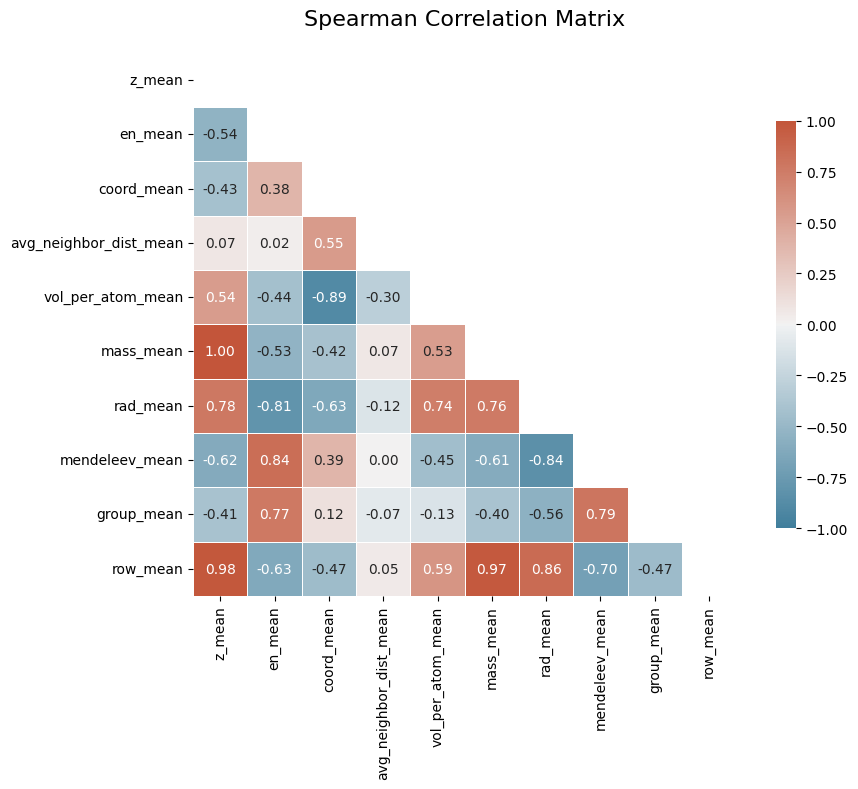

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
from loguru import logger

from src.datasets import MaterialsProject # Make sure these imports match your structure
from scripts.materials_project.evaluation_pipeline import build_invariant_matrix

def plot_invariant_feature_correlation(
    df: pl.DataFrame,
    output_dir: Path = Path("figures/materials/features"),
):
    """
    Extracts aggregated invariant features (MEANS ONLY), computes their 
    Spearman correlation, and plots a heatmap.
    """
    feature_keys = [
        "z", "en", "coord", "avg_neighbor_dist", "vol_per_atom",
        "mass", "rad", "mendeleev", "group", "row"
    ]
        
    logger.info(f"Extracting features for correlation matrix: {feature_keys}")
    
    # 1. Extract the N x (2*D) feature matrix and convert to numpy
    feature_matrix = np.array(build_invariant_matrix(df, aggregated=True, feature_keys=feature_keys))
    
    # Slice to keep ONLY the first half of the columns (the means)
    num_features = len(feature_keys)
    mean_matrix = feature_matrix[:, :num_features]
    
    # 2. Map the column names (only means now)
    col_names = [f"{k}_mean" for k in feature_keys]
    
    # 3. Convert to Pandas for easy correlation calculation
    feat_df = pd.DataFrame(mean_matrix, columns=col_names)
    
    # Calculate Spearman correlation (better for non-linear/ordinal features)
    corr = feat_df.corr(method="spearman")
    
    # 4. Plotting setup (Slightly smaller figure since we have fewer features)
    plt.figure(figsize=(10, 8))
    
    # Create a mask to hide the upper triangle (prevents mirrored redundant data)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    
    sns.heatmap(
        corr, 
        mask=mask, 
        cmap=cmap, 
        vmax=1.0, 
        vmin=-1.0, 
        center=0,
        annot=True,     # Show the correlation numbers
        fmt=".2f",      # Format to 2 decimal places
        annot_kws={"size": 10}, # Increased text size for better readability
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .75}
    )
    
    plt.title("Spearman Correlation Matrix", fontsize=16, pad=20)
    plt.tight_layout()
    
    # Save it
    out_path = output_dir / "invariant_features_correlation_means.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    logger.success(f"Saved feature correlation matrix to {out_path}")
    plt.show()
    plt.close()

if __name__ == '__main__':
    mp = MaterialsProject()
    df = mp.load(limit=25_000, force_fetch=False)
    plot_invariant_feature_correlation(df)

# Stratisfied sampling

In [8]:
mp_full = MaterialsProject(sampling_strategy="head")
df_full = mp_full.load(limit=None, force_fetch=False)

2026-03-31 08:53:31.455 | INFO     | src.datasets:load:1030 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 08:53:32.494 | INFO     | src.datasets:load:1054 - Limit is None. Returning the full dataset (210579 rows) without sampling.


In [9]:
mp_head = MaterialsProject(sampling_strategy="head")
df_first = mp_head.load(limit=5000)

2026-03-31 08:53:38.433 | INFO     | src.datasets:load:1030 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 08:53:39.202 | INFO     | src.datasets:load:1060 - Sampling 5000 rows using head strategy...


In [10]:
mp_strat = MaterialsProject(sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"])
df_strat = mp_strat.load(limit=5000)

2026-03-31 08:53:40.056 | INFO     | src.datasets:load:1030 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 08:53:41.105 | INFO     | src.datasets:load:1060 - Sampling 5000 rows using stratified strategy...


In [11]:
mp_random = MaterialsProject(sampling_strategy="random")
df_random = mp_random.load(limit=5000)

2026-03-31 08:54:11.943 | INFO     | src.datasets:load:1030 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-03-31 08:54:13.040 | INFO     | src.datasets:load:1060 - Sampling 5000 rows using random strategy...


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_2287/4017335222.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_pop[column], label="Original Population", color="gray", shade=True, bw_adjust=0.5)


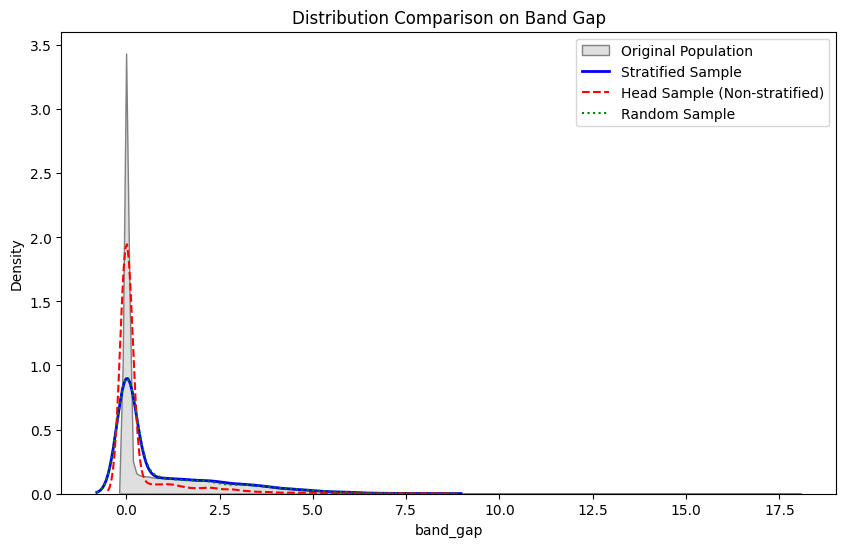

In [21]:
def validate_distributions(df_pop, df_strat, df_head, df_random, column="band_gap"):
    plt.figure(figsize=(10, 6))
    
    sns.kdeplot(df_pop[column], label="Original Population", color="gray", shade=True, bw_adjust=0.5)
    
    sns.kdeplot(df_strat[column], label="Stratified Sample", color="blue", linewidth=2)
    
    sns.kdeplot(df_head[column], label="Head Sample (Non-stratified)", color="red", linestyle="--")

    sns.kdeplot(df_random[column], label="Random Sample", color="green", linestyle=":")
    
    plt.title("Distribution Comparison on Band Gap")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()

    plt.savefig(f'figures/materials/sampling/statified_{column}_validation.png', dpi=300)
    plt.show()

validate_distributions(df_full, df_strat, df_first, df_random)

In [25]:
from scipy.stats import ks_2samp
import polars as pl # Note: Code below uses Polars specific syntax
import pandas as pd 

# 1. Define your columns
columns_to_check = ["band_gap", "energy_above_hull"]

print("=== 1D Marginal Distribution Check (KS Test) ===")
for col in columns_to_check:
    # Use .drop_nulls() for Polars, or .dropna() for Pandas
    pop_values = df_full[col].drop_nulls()
    strat_values = df_strat[col].drop_nulls()
    head_values = df_first[col].drop_nulls()
    rand_values = df_random[col].drop_nulls() # Added df_random
    
    stat_strat = ks_2samp(pop_values, strat_values).statistic
    stat_head = ks_2samp(pop_values, head_values).statistic
    stat_rand = ks_2samp(pop_values, rand_values).statistic # Added df_random
    
    print(f"\nColumn: {col}")
    print(f"  Stratified KS Stat: {stat_strat:.4f} (Closer to 0 is better)")
    print(f"  Random KS Stat:     {stat_rand:.4f}") # Added df_random
    print(f"  Head KS Stat:       {stat_head:.4f}")

print("\n=== 2D Joint Relationship Check (Correlation) ===")

# Unpack the columns for cleaner Polars syntax
col_x, col_y = columns_to_check[0], columns_to_check[1]

# In Polars, we drop nulls in those specific columns, then use the expression API to get the correlation
pop_corr = df_full.drop_nulls(subset=columns_to_check).select(
    pl.corr(col_x, col_y, method="spearman")
).item()

strat_corr = df_strat.drop_nulls(subset=columns_to_check).select(
    pl.corr(col_x, col_y, method="spearman")
).item()

head_corr = df_first.drop_nulls(subset=columns_to_check).select(
    pl.corr(col_x, col_y, method="spearman")
).item()

# Added df_random correlation calculation
rand_corr = df_random.drop_nulls(subset=columns_to_check).select(
    pl.corr(col_x, col_y, method="spearman")
).item()

print(f"Population Correlation: {pop_corr:.4f}")
print(f"Stratified Correlation: {strat_corr:.4f} (Difference: {abs(pop_corr - strat_corr):.4f})")
print(f"Random Correlation:     {rand_corr:.4f} (Difference: {abs(pop_corr - rand_corr):.4f})") # Added df_random
print(f"Head Correlation:       {head_corr:.4f} (Difference: {abs(pop_corr - head_corr):.4f})")

=== 1D Marginal Distribution Check (KS Test) ===

Column: band_gap
  Stratified KS Stat: 0.0056 (Closer to 0 is better)
  Random KS Stat:     0.0135
  Head KS Stat:       0.2468

Column: energy_above_hull
  Stratified KS Stat: 0.0096 (Closer to 0 is better)
  Random KS Stat:     0.0149
  Head KS Stat:       0.5181

=== 2D Joint Relationship Check (Correlation) ===
Population Correlation: -0.0036
Stratified Correlation: -0.0029 (Difference: 0.0007)
Random Correlation:     0.0064 (Difference: 0.0101)
Head Correlation:       -0.1054 (Difference: 0.1017)


1. The Stratified Sample is a "Statistical Twin"
KS Statistic: 0.0148: The maximum gap between your sample's distribution and the true population is a microscopic 1.48%.
P-value: 0.9864: In statistics, a p-value this high essentially means the test gave up trying to find a difference. There is absolutely zero statistical evidence that your sample is different from the full dataset. It is a highly representative miniature version of your stable oxides.
2. The Head Sample is Heavily Biased
KS Statistic: 0.1715: At its worst point, the head sample’s distribution deviates from the true population by over 17%.
P-value: 0.0000: This is the definitive mathematical proof that just grabbing the first N materials from the Materials Project API introduces massive selection bias. If you had trained a model on this, it would have been heavily skewed toward whatever material types were uploaded to the database first.

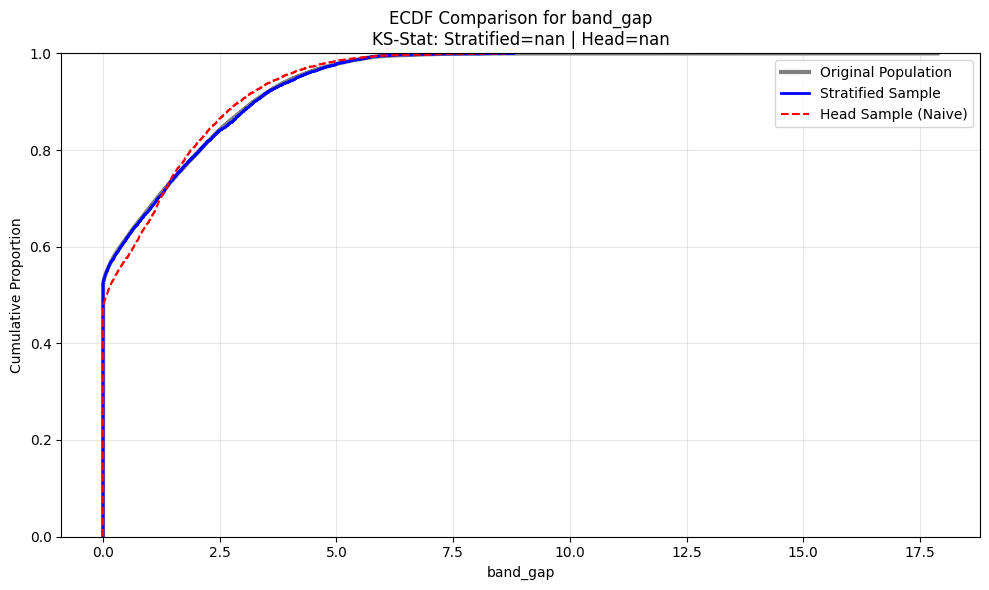

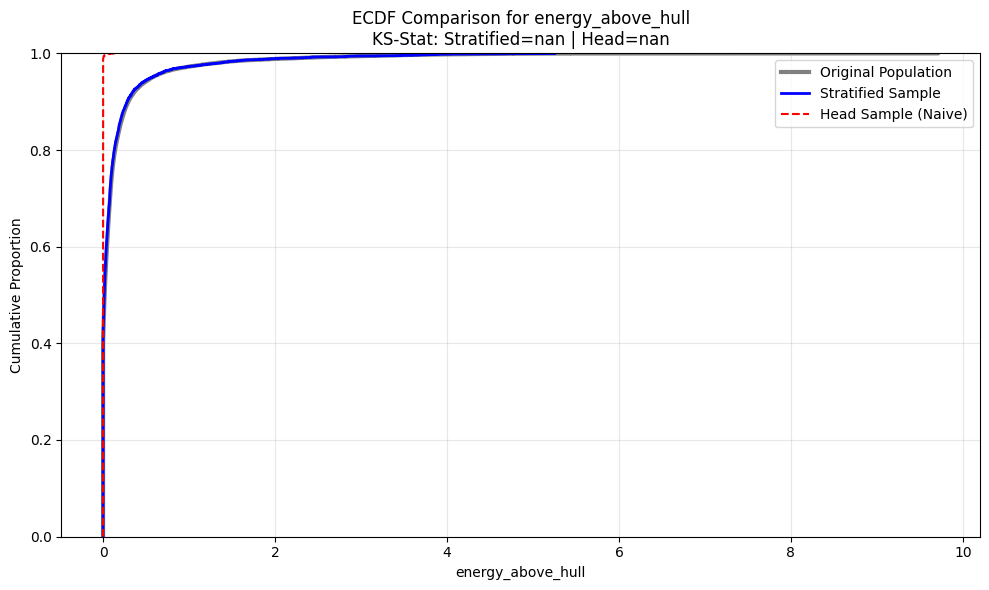

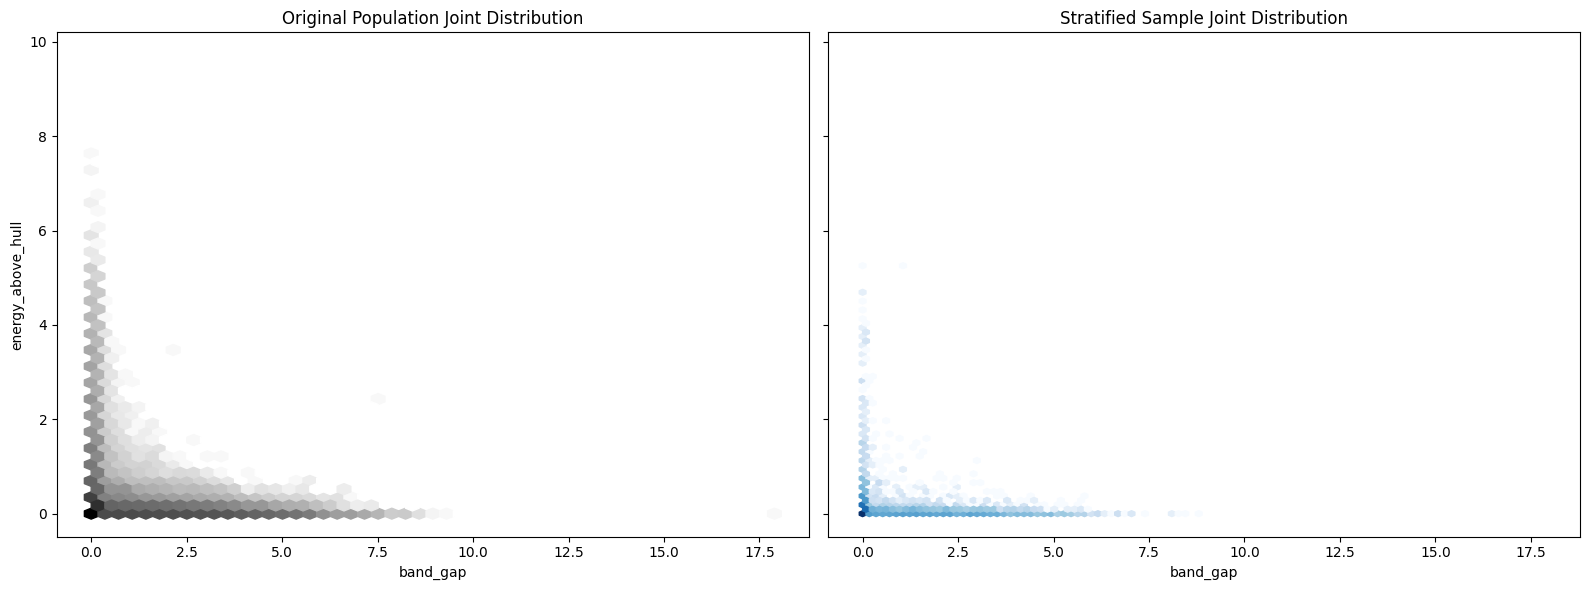

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
import pandas as pd

def validate_1d_distributions(df_pop, df_strat, df_head, columns=["band_gap", "energy_above_hull"]):
    """Visualizes and statistically compares 1D distributions using ECDF."""
    
    for col in columns:
        plt.figure(figsize=(10, 6))
        
        # ECDF is often better than KDE for exact distribution matching
        sns.ecdfplot(df_pop[col], label="Original Population", color="gray", linewidth=3)
        sns.ecdfplot(df_strat[col], label="Stratified Sample", color="blue", linewidth=2)
        sns.ecdfplot(df_head[col], label="Head Sample (Naive)", color="red", linestyle="--")
        
        # Calculate KS-Statistic (lower is better, 0.0 means identical distributions)
        ks_strat = ks_2samp(df_pop[col], df_strat[col]).statistic
        ks_head = ks_2samp(df_pop[col], df_head[col]).statistic
        
        plt.title(f"ECDF Comparison for {col}\nKS-Stat: Stratified={ks_strat:.3f} | Head={ks_head:.3f}")
        plt.xlabel(col)
        plt.ylabel("Cumulative Proportion")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # plt.savefig(f'figures/materials/sampling/stratified_{col}_ecdf.png', dpi=300)
        plt.show()

def validate_2d_distribution(df_pop, df_strat, col_x="band_gap", col_y="energy_above_hull"):
    """Visualizes the joint distribution of the stratified variables."""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
    
    # Population 2D Hexbin
    axes[0].hexbin(df_pop[col_x], df_pop[col_y], gridsize=50, cmap='Greys', bins='log')
    axes[0].set_title("Original Population Joint Distribution")
    axes[0].set_xlabel(col_x)
    axes[0].set_ylabel(col_y)
    
    # Stratified Sample 2D Hexbin
    axes[1].hexbin(df_strat[col_x], df_strat[col_y], gridsize=50, cmap='Blues', bins='log')
    axes[1].set_title("Stratified Sample Joint Distribution")
    axes[1].set_xlabel(col_x)
    
    plt.tight_layout()
    # plt.savefig('figures/materials/sampling/stratified_2d_validation.png', dpi=300)
    plt.show()

# Run the validations
stratified_cols = ["band_gap", "energy_above_hull"]

# 1. Validate the targeted columns
validate_1d_distributions(mp.df, df_strat, df_first, columns=stratified_cols)

# 2. Validate the 2D joint distribution
validate_2d_distribution(mp.df, df_strat, col_x=stratified_cols[0], col_y=stratified_cols[1])